In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [112]:
df_Employee = pd.read_csv('../data/EmployeeData.csv')
df_Employee.head()

,ID,Name,Age,Salary,Department
0,384,Alice,28.0,32000.0,Sales
1,611,Frank,40.0,32000.0,Sales
2,453,Jane,30.0,NaN,Finance
3,853,Kyle,28.0,NaN,Sales
4,437,David,NaN,50000.0,Finance


In [113]:
# Explore the dataset
df_Employee.info()


<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1050 non-null   int64  
 1   Name        1050 non-null   str    
 2   Age         927 non-null    float64
 3   Salary      894 non-null    float64
 4   Department  1050 non-null   str    
dtypes: float64(2), int64(1), str(2)
memory usage: 41.1 KB


In [114]:
df_Employee.describe()

,ID,Age,Salary
count,1050.000000,927.000000,894.000000
mean,502.380952,31.928803,46534.675615
std,288.838378,7.543631,14762.487836
min,1.000000,22.000000,28000.000000
25%,253.250000,25.000000,32000.000000
50%,503.500000,30.000000,40000.000000
75%,751.750000,40.000000,60000.000000
max,1000.000000,45.000000,70000.000000


In [116]:
# detecting missed values 
print("Column baesed null values:", df_Employee.isnull().sum())
print("Dataset Null values null values:", df_Employee.isnull().sum().sum())

Column baesed null values: ID              0
Name            0
Age           123
Salary        156
Department      0
dtype: int64
Dataset Null values null values: 279


## Solutions for outliers detection
1. Boxplot
2. IQR
3. Z-score: (x-mean / std)

Index(['ID', 'Age', 'Salary'], dtype='str')


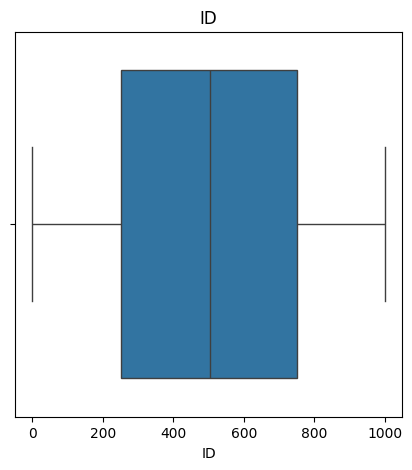

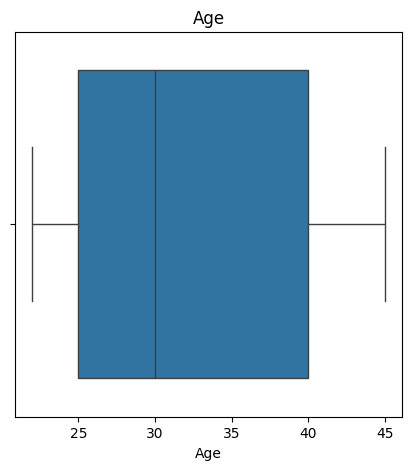

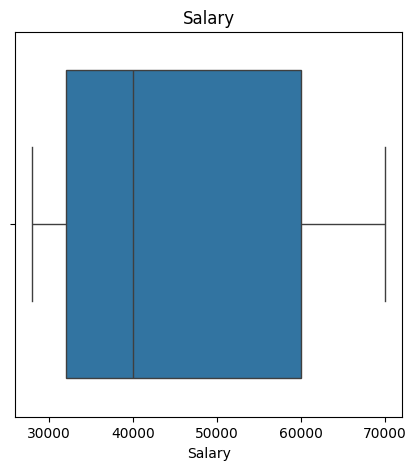

In [89]:
# box plot for outliers detection for all numeric columns

numeric_col = df_Employee.select_dtypes(include = 'number').columns
print(numeric_col)
for col in numeric_col:
    plt.figure(figsize=(5,5))
    sns.boxplot(data=df_Employee, x=col)
    plt.title(col)
    plt.show()




In [ ]:
# IQR
Q1 = df_Employee['Salary'].quantile(0.25)
Q3 = df_Employee['Salary'].quantile(0.75)

IQR = Q3 - Q1

Lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_Employee[(df_Employee["Salary"] < Lower_bound) |
              (df_Employee["Salary"] > upper_bound)  ]

print(outliers)

Empty DataFrame
Columns: [ID, Name, Age, Salary, Department]
Index: []


In [118]:
# Handeling Missing vaues 
# df_Employee =  df_Employee['Age'].fillna(df_Employee['Age'].median(), inplace=True)
df_Employee =  df_Employee.fillna(df_Employee.mean(numeric_only=True))
df_Employee.head()
df_Employee.info()
# removing null values 
# Notice the changed after inplace = True


<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1050 non-null   int64  
 1   Name        1050 non-null   str    
 2   Age         1050 non-null   float64
 3   Salary      1050 non-null   float64
 4   Department  1050 non-null   str    
dtypes: float64(2), int64(1), str(2)
memory usage: 41.1 KB


In [119]:
# Detect and remove Duplicate
df_Employee.duplicated().sum()

np.int64(50)

In [120]:
df_Employee.drop_duplicates(inplace=True)

In [121]:
df_Employee.info()
df_Employee.head(10)

<class 'pandas.DataFrame'>
Index: 1000 entries, 0 to 1049
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1000 non-null   int64  
 1   Name        1000 non-null   str    
 2   Age         1000 non-null   float64
 3   Salary      1000 non-null   float64
 4   Department  1000 non-null   str    
dtypes: float64(2), int64(1), str(2)
memory usage: 46.9 KB


,ID,Name,Age,Salary,Department
0,384,Alice,28.000000,32000.000000,Sales
1,611,Frank,40.000000,32000.000000,Sales
2,453,Jane,30.000000,46534.675615,Finance
3,853,Kyle,28.000000,46534.675615,Sales
4,437,David,31.928803,50000.000000,Finance
5,692,Frank,30.000000,70000.000000,IT
6,908,Laura,40.000000,40000.000000,Operations
7,519,Helen,28.000000,40000.000000,HR
8,23,Helen,30.000000,46534.675615,Marketing
9,172,Bob,45.000000,70000.000000,IT


In [122]:
df_Employee.isnull().sum()
df_Employee.duplicated().sum()

np.int64(0)

## Data Integration 

In [ ]:
# Data integration in python
# pd.merge(Data1, Data2, on=“column_ID”, how=“outer”)
# on: is common column
# how: type of join:
# left: all from left dataset and common from right
# right: all from right dataset and common from left
# inner: just common records
# outer: all records from both datasets

In [ ]:
customer_info = pd.read_csv('../data/Customer_Info.csv')
customer_sale= pd.read_csv('../data/Customer_Sales.csv')

In [102]:
customer_info.head()

,Customer_ID,Name,Age,City
0,1001,Charlie,25,London
1,1002,Charlie,42,Bristol
2,1003,Grace,35,London
3,1004,Bob,45,Manchester
4,1005,David,20,Leeds


In [103]:
customer_sales.head()

,Customer_ID,Total_Spend,Last_Purchase
0,1051,3458,2024-01-01
1,1052,564,2024-01-08
2,1053,3330,2024-01-15
3,1054,3184,2024-01-22
4,1055,3639,2024-01-29


In [101]:
customer_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Customer_ID  100 non-null    int64
 1   Name         100 non-null    str  
 2   Age          100 non-null    int64
 3   City         100 non-null    str  
dtypes: int64(2), str(2)
memory usage: 3.3 KB


In [104]:
customer_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Customer_ID    100 non-null    int64
 1   Total_Spend    100 non-null    int64
 2   Last_Purchase  100 non-null    str  
dtypes: int64(2), str(1)
memory usage: 2.5 KB


In [ ]:
customer_info.duplicated().sum()

np.int64(0)

In [106]:
customer_sales.duplicated().sum()

np.int64(0)

In [131]:
# Merge the datasets
merged_data = pd.merge(customer_info, customer_sales, on="Customer_ID", how="inner")

merged_data.head()


,Customer_ID,Name,Age,City,Total_Spend,Last_Purchase
0,1051,Alice,57,Birmingham,3458,2024-01-01
1,1052,Grace,22,Bristol,564,2024-01-08
2,1053,Eva,38,Liverpool,3330,2024-01-15
3,1054,Helen,55,Bristol,3184,2024-01-22
4,1055,Grace,38,London,3639,2024-01-29


In [132]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Customer_ID    50 non-null     int64
 1   Name           50 non-null     str  
 2   Age            50 non-null     int64
 3   City           50 non-null     str  
 4   Total_Spend    50 non-null     int64
 5   Last_Purchase  50 non-null     str  
dtypes: int64(3), str(3)
memory usage: 2.5 KB


In [130]:
# duplicated rows
merged_data.duplicated().sum()


np.int64(0)

## Data Transformation

In [2]:
df_Ac3 = pd.read_csv('../data/Workshop 4 Activity 3 Data.csv')

In [3]:
# disply the first 5 rows
df_Ac3.head()

,Student_ID,Gender,Grade,Employed
0,1,M,First,N
1,2,M,Second,Y
2,3,M,Second,Y
3,4,F,Fail,N
4,5,M,First,Y


In [4]:
df_categorical = df_Ac3.select_dtypes(exclude =[np.number])
df_categorical.head()


,Gender,Grade,Employed
0,M,First,N
1,M,Second,Y
2,M,Second,Y
3,F,Fail,N
4,M,First,Y


In [9]:
# printing the unique values 
display(df_categorical["Gender"].unique())

<StringArray>
['M', 'F']
Length: 2, dtype: str

In [10]:
# printing the unique values 
display(df_categorical["Grade"].unique())

<StringArray>
['First', 'Second', 'Fail', 'Third']
Length: 4, dtype: str

In [11]:
# printing the unique values 
display(df_categorical["Employed"].unique())

<StringArray>
['N', 'Y']
Length: 2, dtype: str

In [21]:
df_categorical["Gender"] = df_categorical["Gender"].replace({"M": 1, "F": 0})

In [22]:
df_categorical["Grade"] = df_categorical["Grade"].replace({"First": 1, "Second": 2, "Third": 3, "Fail": 4})

In [23]:
df_categorical["Employed"] = df_categorical["Employed"].replace({"N": 0, "Y": 1})

In [24]:
df_categorical.head(20)

,Gender,Grade,Employed
0,1,1,0
1,1,2,1
2,1,2,1
3,0,4,0
4,1,1,1
5,0,1,0
6,0,2,0
7,1,3,0
8,0,1,0
9,0,1,1


In [ ]:
# PCA for data reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize
X_scaled = StandardScaler().fit_transform(df_categorical)

# PCA
pca = PCA(n_components=1)

# Create PCA dataframe
df_pca = pd.DataFrame(
    pca.fit_transform(X_scaled),
    columns=['PCA_1']
)

# Combine original data with PCA result
df_final = pd.concat([df_categorical, df_pca], axis=1)

print(df_final.head())
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_[0]:.4f}")

  Gender Grade Employed     PCA_1
0      1     1        0  0.479797
1      1     2        1  1.452349
2      1     2        1  1.452349
3      0     4        0 -2.216695
4      1     1        1  2.041494
Explained Variance Ratio: 0.4083


In [36]:
#Activity #4
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [38]:
# Load dataset
df = pd.read_csv("../data/Activity4_Data_Transformation.csv")

In [39]:
# 1. Normalisation of Salary
salary_scaler = MinMaxScaler()

df['Salary_Normalised'] = salary_scaler.fit_transform(
    df[['Salary']]
)

In [40]:
# 2. Standardisation of Age
age_scaler = StandardScaler()

df['Age_Standardised'] = age_scaler.fit_transform(
    df[['Age']]
)


In [41]:
# 3. Discretisation of Age
bins = [0, 35, 50, 100]
labels = ['Young', 'Middle-aged', 'Senior']

df['Age_Category'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)


In [42]:
# View Results
print(df.head(10))

# Optional checks
print("\nSalary Normalised Range:")
print(df['Salary_Normalised'].min())
print(df['Salary_Normalised'].max())

print("\nAge Category Counts:")
print(df['Age_Category'].value_counts())

   Employee_ID     Name  Age  Salary Department  Salary_Normalised  \
0            1    Grace   41   99740  Marketing           0.787131   
1            2    David   30   91617         HR           0.701109   
2            3    Helen   35  119841         HR           1.000000   
3            4      Eva   52   41896      Sales           0.174565   
4            5    Grace   28   71175  Marketing           0.484629   
5            6     Jane   25   32805  Marketing           0.078292   
6            7  Charlie   35   30237  Marketing           0.051097   
7            8    Grace   48   45056    Finance           0.208029   
8            9    Helen   22   70543      Sales           0.477936   
9           10      Eva   39   81556  Marketing           0.594563   

   Age_Standardised Age_Category  
0         -0.160891  Middle-aged  
1         -1.056996        Young  
2         -0.649676        Young  
3          0.735213       Senior  
4         -1.219924        Young  
5         -1.464316

Reflection (Example)

You can present something like:

Normalisation was applied to the Salary attribute using Min-Max Scaling, which transformed all salary values to a range between 0 and 1. This is useful when attributes have different scales and are used in machine learning algorithms.

Standardisation was applied to the Age attribute. This transformation converts the data to have a mean of approximately 0 and a standard deviation of 1, making it suitable for algorithms that assume normally distributed data.

Discretisation was applied to Age by converting continuous numerical values into three categories:

Young (≤ 35)
Middle-aged (36–50)
Senior (> 50)

This transformation simplifies analysis and allows age groups to be treated as categorical variables for reporting and classification tasks.